# CP2. Тюнинг моделей и финальные эксперименты

В этом ноутбуке проводится более полный подбор гиперпараметров для лучших моделей из CP1.

Цель — улучшить качество по ROC-AUC, выбрать финальную модель на validation-выборке и затем проверить её качество на test-выборке.

#### Основная метрика

Для сравнения и выбора моделей используется ROC-AUC, потому что в проекте решается задача бинарной классификации, а модели возвращают вероятность принадлежности пассажира к классу `satisfied`.

ROC-AUC оценивает качество ранжирования объектов: удовлетворённые пассажиры должны получать более высокие predicted probabilities, чем неудовлетворённые. Метрика удобна на этапе сравнения моделей, потому что не зависит от конкретного порога для перевода вероятности в класс.

Accuracy, Precision, Recall и F1-score используются как дополнительные метрики для проверки качества итоговых бинарных предсказаний. При выборе финальной модели приоритет отдаётся ROC-AUC.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import randint
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 506

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_TABLES_DIR = PROJECT_ROOT / "report" / "tables"
REPORT_IMAGES_DIR = PROJECT_ROOT / "report" / "images"
MODELS_DIR = PROJECT_ROOT / "models"

REPORT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)


## Загрузка подготовленных данных

Используются train / validation / test выборки, подготовленные в `notebooks/01_EDA.ipynb`.

Test-выборка не используется для подбора гиперпараметров. Она нужна только для финальной оценки выбранной модели.


In [7]:
train_data = pd.read_csv(PROCESSED_DATA_DIR / "train.csv")
val_data = pd.read_csv(PROCESSED_DATA_DIR / "val.csv")
test_data = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")

target_column = "target"

X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]

X_val = val_data.drop(columns=[target_column])
y_val = val_data[target_column]

X_test = test_data.drop(columns=[target_column])
y_test = test_data[target_column]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (90916, 25) (90916,)
Validation: (19482, 25) (19482,)
Test: (19482, 25) (19482,)


## Preprocessing pipeline

Все преобразования признаков выполняются внутри `sklearn Pipeline`.

Для числовых признаков используется заполнение пропусков медианой и масштабирование. Для категориальных признаков используется заполнение наиболее частым значением и OneHotEncoding.


In [8]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)


In [9]:
def evaluate_predictions(model_name, y_true, y_pred, y_score, dataset_name):
    return {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def evaluate_pipeline(model_name, pipeline, X_data, y_data, dataset_name):
    y_pred = pipeline.predict(X_data)
    y_score = pipeline.predict_proba(X_data)[:, 1]

    return evaluate_predictions(
        model_name=model_name,
        y_true=y_data,
        y_pred=y_pred,
        y_score=y_score,
        dataset_name=dataset_name,
    )


## RandomizedSearchCV для RandomForest

В CP1 одной из лучших моделей был RandomForest. Поэтому в CP2 для него проводится более полноценный подбор гиперпараметров через `RandomizedSearchCV`.

Подбираются глубина деревьев, количество деревьев, минимальное число объектов в листе, минимальное число объектов для split и доля признаков для построения split.


In [10]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)

rf_param_distributions = {
    "model__n_estimators": randint(150, 401),
    "model__max_depth": [10, 12, 14, 16, 18, None],
    "model__min_samples_split": randint(2, 12),
    "model__min_samples_leaf": randint(1, 6),
    "model__max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

rf_search.best_score_, rf_search.best_params_


Fitting 3 folds for each of 20 candidates, totalling 60 fits


(np.float64(0.9908779481026057),
 {'model__max_depth': 16,
  'model__max_features': None,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 7,
  'model__n_estimators': 279})

### Вывод по тюнингу RandomForest

Для RandomForest был проведён подбор гиперпараметров с помощью `RandomizedSearchCV`.

Лучшее среднее качество на кросс-валидации:

- ROC-AUC: 0.990878.

Лучшие параметры:

- `max_depth`: 16;
- `max_features`: None;
- `min_samples_leaf`: 1;
- `min_samples_split`: 7;
- `n_estimators`: 279.

По сравнению с CP1 модель стала более гибкой за счёт увеличения глубины деревьев. При этом ограничение `min_samples_split=7` помогает немного снизить риск переобучения.

## RandomizedSearchCV для GradientBoosting

GradientBoosting также показал хорошее качество на CP1, поэтому для него проводится отдельный подбор гиперпараметров.

Подбираются количество деревьев, learning rate, глубина деревьев, минимальное число объектов в листе и split.


In [11]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]
)

gb_param_distributions = {
    "model__n_estimators": randint(80, 251),
    "model__learning_rate": [0.03, 0.05, 0.07, 0.1, 0.15],
    "model__max_depth": randint(2, 6),
    "model__min_samples_split": randint(2, 12),
    "model__min_samples_leaf": randint(1, 6),
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

gb_search.fit(X_train, y_train)

gb_search.best_score_, gb_search.best_params_


Fitting 3 folds for each of 15 candidates, totalling 45 fits


(np.float64(0.991214865107149),
 {'model__learning_rate': 0.07,
  'model__max_depth': 5,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 4,
  'model__n_estimators': 250})

### Вывод по тюнингу GradientBoosting

Для GradientBoosting также был проведён подбор гиперпараметров через `RandomizedSearchCV`.

Лучшее среднее качество на кросс-валидации:

- ROC-AUC: 0.991215.

Лучшие параметры:

- `n_estimators`: 250;
- `learning_rate`: 0.07;
- `max_depth`: 5;
- `min_samples_leaf`: 1;
- `min_samples_split`: 4.

GradientBoosting показал немного более высокий ROC-AUC на кросс-валидации, чем RandomForest. Это может говорить о том, что последовательное построение деревьев лучше улавливает сложные зависимости в данных.

## Сравнение tuned-моделей на validation

После подбора гиперпараметров модели сравниваются на validation-выборке. Test-выборка всё ещё не используется.


In [12]:
validation_results = []

for model_name, fitted_search in [
    ("random_forest_tuned", rf_search),
    ("gradient_boosting_tuned", gb_search),
]:
    best_pipeline = fitted_search.best_estimator_
    metrics = evaluate_pipeline(
        model_name=model_name,
        pipeline=best_pipeline,
        X_data=X_val,
        y_data=y_val,
        dataset_name="validation",
    )
    metrics["best_cv_roc_auc"] = fitted_search.best_score_
    metrics["best_params"] = fitted_search.best_params_
    validation_results.append(metrics)

validation_results = pd.DataFrame(validation_results).sort_values(
    "roc_auc",
    ascending=False,
)

validation_results


,model,dataset,accuracy,precision,recall,f1,roc_auc,best_cv_roc_auc,best_params
1,gradient_boosting_tuned,validation,0.950416,0.963483,0.945231,0.954270,0.991339,0.991215,"{'model__learning_rate': 0.07, 'model__max_dep..."
0,random_forest_tuned,validation,0.950672,0.963589,0.945606,0.954513,0.991223,0.990878,"{'model__max_depth': 16, 'model__max_features'..."


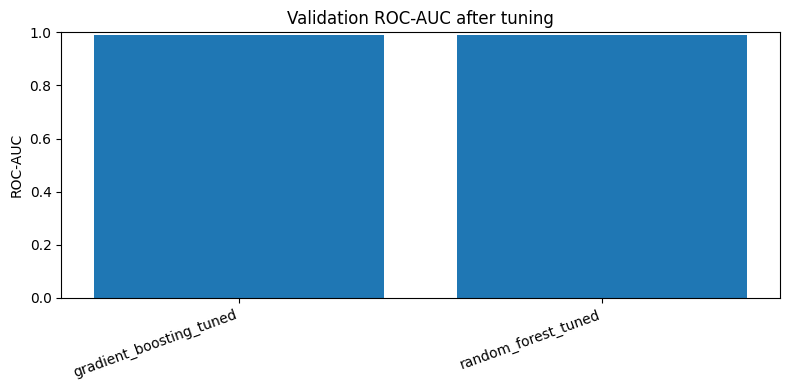

In [13]:
validation_results.to_csv(
    REPORT_TABLES_DIR / "cp2_tuned_validation_results.csv",
    index=False,
)

plt.figure(figsize=(8, 4))
plt.bar(validation_results["model"], validation_results["roc_auc"])
plt.title("Validation ROC-AUC after tuning")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / "cp2_tuned_validation_roc_auc.png", dpi=200)
plt.show()


### Сравнение tuned-моделей на validation

На validation-выборке обе tuned-модели показали очень близкое качество.

`GradientBoosting` получил лучший ROC-AUC:

- ROC-AUC: 0.991339;
- F1-score: 0.954270;
- Accuracy: 0.950416.

`RandomForest` немного лучше по threshold-based метрикам:

- Accuracy: 0.950672;
- F1-score: 0.954513;
- Precision: 0.963589;
- Recall: 0.945606.

Так как основная метрика это ROC-AUC, финальной моделью на этом этапе выбирается `gradient_boosting_tuned`. Разница между моделями небольшая, но GradientBoosting немного лучше ранжирует объекты по вероятности принадлежности к положительному классу.

## Финальная оценка на test

После выбора лучшей tuned-модели по validation ROC-AUC она один раз оценивается на test-выборке.

Test не использовался при подборе гиперпараметров, поэтому эта оценка является более честной проверкой качества выбранной модели.


In [14]:
best_model_name = validation_results.iloc[0]["model"]

if best_model_name == "random_forest_tuned":
    final_pipeline = rf_search.best_estimator_
else:
    final_pipeline = gb_search.best_estimator_

test_results = pd.DataFrame(
    [
        evaluate_pipeline(
            model_name=best_model_name,
            pipeline=final_pipeline,
            X_data=X_test,
            y_data=y_test,
            dataset_name="test",
        )
    ]
)

test_results


,model,dataset,accuracy,precision,recall,f1,roc_auc
0,gradient_boosting_tuned,test,0.950108,0.960205,0.948138,0.954134,0.991728


In [18]:
test_results.to_csv(
    REPORT_TABLES_DIR / "cp2_final_test_results.csv",
    index=False,
)


### Финальная оценка на test

После выбора лучшей модели по validation ROC-AUC модель `gradient_boosting_tuned` была оценена на test-выборке.

Результаты на test:

- ROC-AUC: 0.991728;
- F1-score: 0.954134;
- Accuracy: 0.950108;
- Precision: 0.960205;
- Recall: 0.948138.

Качество на test-выборке близко к качеству на validation, поэтому признаков сильного переобучения не наблюдается. Модель хорошо обобщается на отложенную выборку.

## Анализ важности признаков

Для tree-based моделей можно оценить важность признаков. Это помогает понять, какие признаки сильнее всего влияют на предсказание удовлетворённости.

Так как в pipeline есть OneHotEncoding, сначала извлекаются имена признаков после preprocessing.


In [16]:
fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
fitted_model = final_pipeline.named_steps["model"]

numeric_feature_names = fitted_preprocessor.named_transformers_[
    "numeric"
].get_feature_names_out(numeric_features)

categorical_feature_names = fitted_preprocessor.named_transformers_[
    "categorical"
].named_steps["onehot"].get_feature_names_out(categorical_features)

feature_names = list(numeric_feature_names) + list(categorical_feature_names)

feature_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": fitted_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance.head(20)


,feature,importance
7,inflight_entertainment,0.471405
2,seat_comfort,0.219819
9,ease_of_online_booking,0.070300
26,class_Business,0.024164
3,departure_arrival_time_convenient,0.021650
13,checkin_service,0.019254
8,online_support,0.019246
10,on_board_service,0.018713
11,leg_room_service,0.016776
23,customer_type_disloyal Customer,0.015557


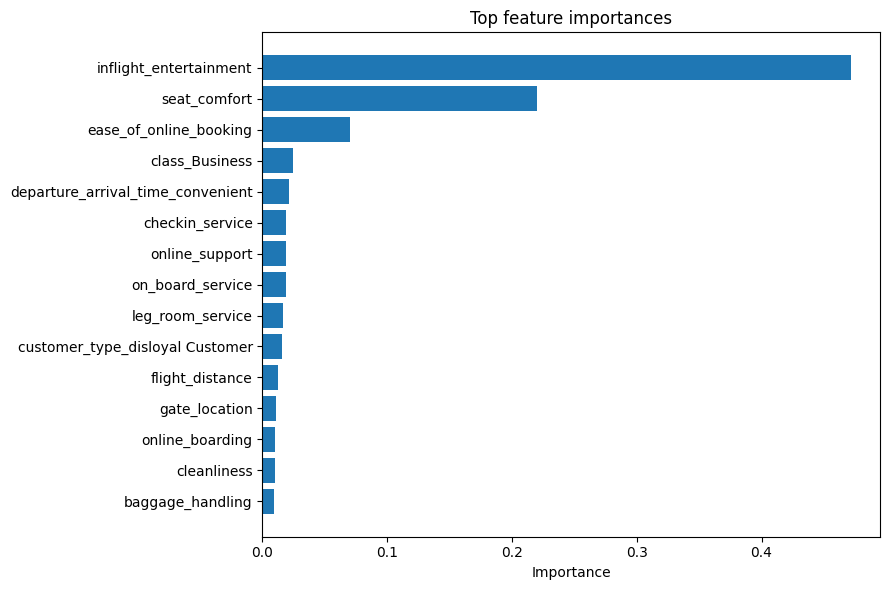

In [17]:
feature_importance.to_csv(
    REPORT_TABLES_DIR / "cp2_feature_importance.csv",
    index=False,
)

top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / "cp2_feature_importance.png", dpi=200)
plt.show()


### Анализ важности признаков

Наиболее важными признаками для финальной модели оказались:

1. `inflight_entertainment`;
2. `seat_comfort`;
3. `ease_of_online_booking`;
4. `class_Business`;
5. `departure_arrival_time_convenient`.

Самый большой вклад даёт признак `inflight_entertainment`: его importance около 0.47. Это означает, что оценка развлечений на борту является одним из ключевых факторов, связанных с удовлетворённостью пассажира.

Второй по важности признак — `seat_comfort`, его importance около 0.22. Это логично, потому что комфорт кресла очень важен во время перелета.

Также заметный вклад дают признаки, связанные с онлайн-сервисами, классом обслуживания и удобством расписания. Это показывает, что удовлетворённость пассажира определяется не только задержками, но и качеством сервиса на разных этапах поездки.

## Выводы

В CP2 был проведён полноценный подбор гиперпараметров для двух сильных моделей: RandomForest и GradientBoosting. Для подбора использовался `RandomizedSearchCV` с оптимизацией по ROC-AUC.

По результатам кросс-валидации:

- RandomForest: ROC-AUC = 0.990878;
- GradientBoosting: ROC-AUC = 0.991215.

На validation-выборке обе модели показали близкое качество. RandomForest немного лучше по Accuracy и F1-score, однако GradientBoosting показал более высокий ROC-AUC — 0.991339 против 0.991223.

Так как ROC-AUC является основной метрикой проекта, финальной моделью выбран `gradient_boosting_tuned`.

На test-выборке финальная модель показала следующие результаты:

- ROC-AUC: 0.991728;
- F1-score: 0.954134;
- Accuracy: 0.950108;
- Precision: 0.960205;
- Recall: 0.948138.

Качество на test близко к качеству на validation, поэтому модель можно считать устойчивой.

Анализ важности признаков показал, что наибольший вклад в предсказание удовлетворённости дают признаки, связанные с качеством сервиса: `inflight_entertainment`, `seat_comfort`, `ease_of_online_booking`, а также признак бизнес-класса. Это согласуется с предметной областью: пассажирская удовлетворённость сильнее всего связана с комфортом и качеством обслуживания.